# Repository Analysis

Analysis of input repository data from CSV files in `data/` directory.

Each `{repo}_scan.csv` contains: sha, smells_before, smells_after, srr, n_structural, structural_types

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set_theme(style='whitegrid')

base_dir = Path.cwd().parent
data_dir = base_dir / 'data'
results_dir = base_dir / 'results'
plots_dir = data_dir / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)
print(f'Data dir: {data_dir}')
print(f'Plots dir: {plots_dir}')

Data dir: /home/sing/refactor_project/data
Plots dir: /home/sing/refactor_project/data/plots


## Load Repository Data

In [2]:
csv_files = list(data_dir.glob('*_scan.csv'))
print(f'Found {len(csv_files)} repository scan files')

dfs = []
for f in csv_files:
    repo_name = f.stem.replace('_scan', '')
    df = pd.read_csv(f)
    df['repo'] = repo_name
    dfs.append(df)
    print(f'  {repo_name}: {len(df)} commits')

if dfs:
    all_data = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal commits: {len(all_data)}')
    print(f'Columns: {list(all_data.columns)}')
    all_data.head()

Found 20 repository scan files
  incubator-gobblin: 9 commits
  incubator-druid: 12 commits
  apex-core: 12 commits
  ode: 12 commits
  incubator-pinot: 12 commits
  camel: 223 commits
  incubator-taverna-language: 9 commits
  myfaces-trinidad: 75 commits
  incubator-dolphinscheduler: 6 commits
  brooklyn-library: 3 commits
  systemml: 6 commits
  oozie: 12 commits
  incubator-shardingsphere: 6 commits
  falcon: 3 commits
  incubator-brooklyn: 15 commits
  servicecomb-pack: 3 commits
  incubator-iotdb: 12 commits
  apex-malhar: 3 commits
  deltaspike: 3 commits
  myfaces-extcdi: 15 commits

Total commits: 451
Columns: ['sha', 'smells_before', 'smells_after', 'srr', 'n_structural', 'structural_types', 'repo']


## Commits per Repository

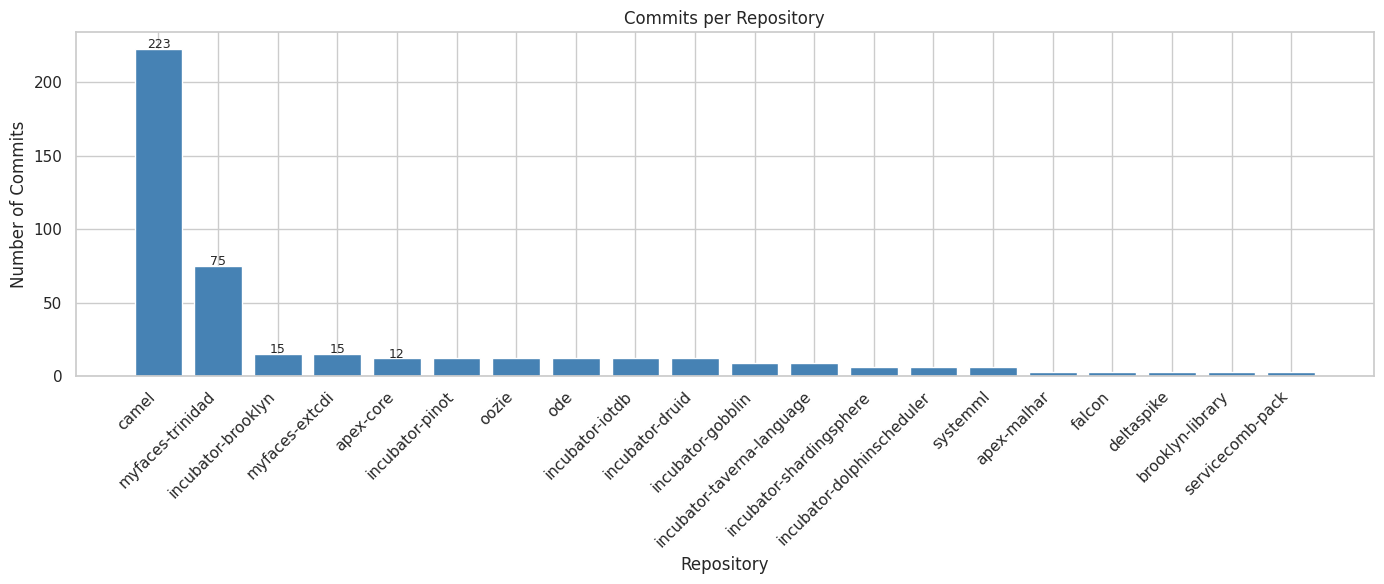


Top 5 repositories:
  camel: 223 commits
  myfaces-trinidad: 75 commits
  incubator-brooklyn: 15 commits
  myfaces-extcdi: 15 commits
  apex-core: 12 commits


In [3]:
commit_counts = all_data.groupby('repo').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x_pos = range(len(commit_counts))
bars = ax.bar(x_pos, commit_counts.values, color='steelblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(commit_counts.index, rotation=45, ha='right')
ax.set_xlabel('Repository')
ax.set_ylabel('Number of Commits')
ax.set_title('Commits per Repository')

# Add value labels on top 5
for i, (bar, val) in enumerate(zip(bars[:5], commit_counts.values[:5])):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(plots_dir/'commits_per_repo.png', dpi=150)
plt.show()

print(f'\nTop 5 repositories:')
for repo, count in commit_counts.head().items():
    print(f'  {repo}: {count} commits')

## Refactoring Types Analysis

Found 15 unique refactoring types


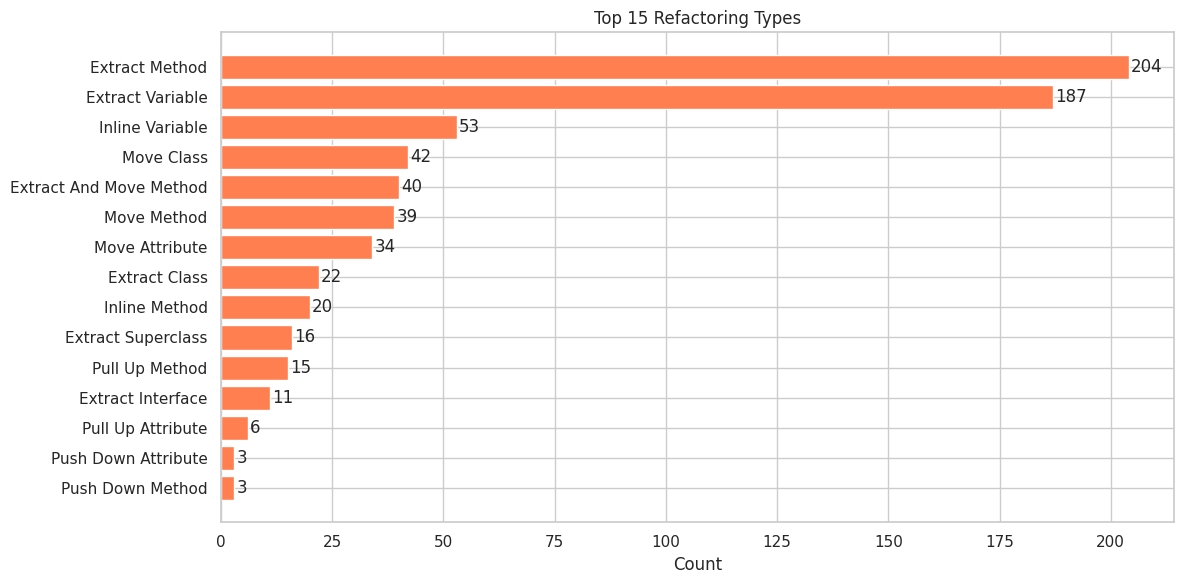


All refactoring types:


Extract Method             204
Extract Variable           187
Inline Variable             53
Move Class                  42
Extract And Move Method     40
Move Method                 39
Move Attribute              34
Extract Class               22
Inline Method               20
Extract Superclass          16
Pull Up Method              15
Extract Interface           11
Pull Up Attribute            6
Push Down Attribute          3
Push Down Method             3
Name: count, dtype: int64

In [4]:
# Parse structural_types column
if 'structural_types' in all_data.columns:
    all_types = []
    for types_str in all_data['structural_types'].dropna():
        if isinstance(types_str, str) and types_str:
            # Handle different possible formats
            types_str = types_str.strip('[]')
            for t in types_str.split(','):
                t = t.strip().strip("'\"")
                if t:
                    all_types.append(t)
    
    if all_types:
        type_counts = pd.Series(all_types).value_counts()
        print(f'Found {len(type_counts)} unique refactoring types')
        
        # Plot top 15 refactoring types
        fig, ax = plt.subplots(figsize=(12, 6))
        top_types = type_counts.head(15)
        bars = ax.barh(range(len(top_types)), top_types.values, color='coral')
        ax.set_yticks(range(len(top_types)))
        ax.set_yticklabels(top_types.index)
        ax.invert_yaxis()
        ax.set_xlabel('Count')
        ax.set_title('Top 15 Refactoring Types')
        
        # Add value labels
        for bar, val in zip(bars, top_types.values):
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center')
        
        plt.tight_layout()
        plt.savefig(plots_dir/'refactoring_types.png', dpi=150)
        plt.show()
        
        print('\nAll refactoring types:')
        display(type_counts)
    else:
        print('No refactoring types found in structural_types column')
else:
    print('structural_types column not found')

---
## Experiment Data Analysis

Analysis of smells distribution for each experiment (Random, Filtered, Mixed)

In [5]:
# Load experiment data
EXP_NAMES = {'experiment_1': 'Random', 'experiment_2': 'Filtered', 'experiment_3': 'Mixed'}
EXP_ORDER = ['Random', 'Filtered', 'Mixed']
EXP_COLORS = {'Random': '#3498db', 'Filtered': '#e74c3c', 'Mixed': '#2ecc71'}

exp_data = {}
for exp_folder, exp_name in EXP_NAMES.items():
    results_file = results_dir / exp_folder / 'results.json'
    if results_file.exists():
        with open(results_file) as f:
            data = json.load(f)
        # Get unique commits (use ollama data for smells_before since it's the same)
        commits = data.get('ollama', [])
        exp_data[exp_name] = pd.DataFrame(commits)
        print(f'{exp_name}: {len(commits)} commits')

print(f'\nLoaded {len(exp_data)} experiments')

Random: 20 commits
Filtered: 100 commits
Mixed: 71 commits

Loaded 3 experiments


### Random Experiment - Smells Distribution

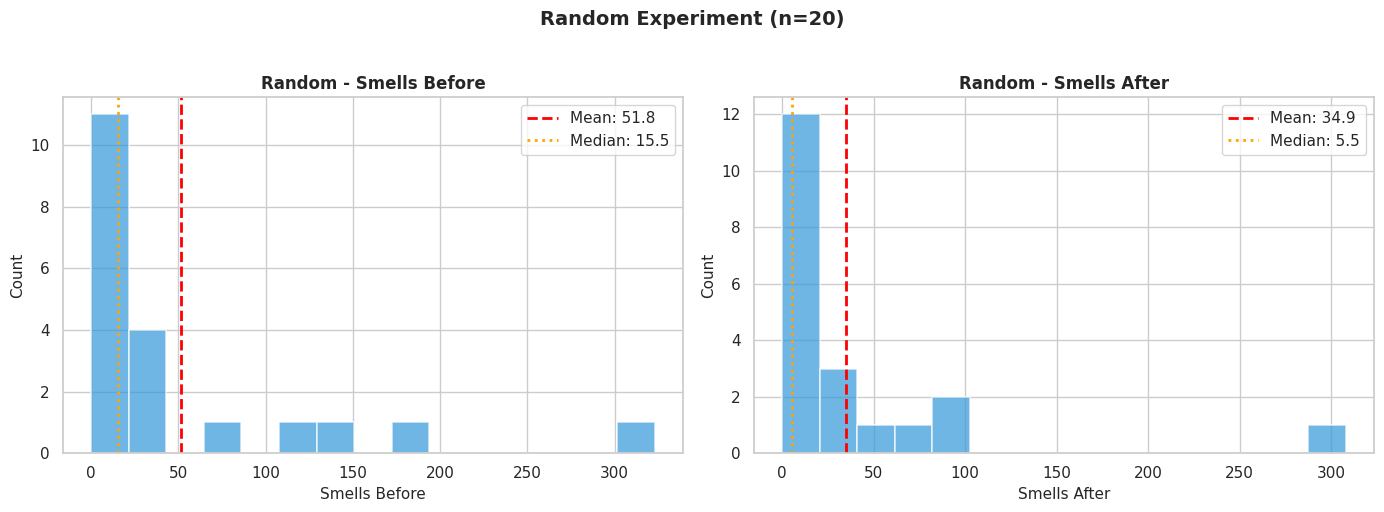

Random - Smells Before: mean=51.8, median=15.5, std=82.5
Random - Smells After:  mean=34.9, median=5.5, std=70.9


In [6]:
if 'Random' in exp_data:
    df = exp_data['Random']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Smells Before
    ax = axes[0]
    smells = df['smells_before'].dropna()
    ax.hist(smells, bins=15, color=EXP_COLORS['Random'], alpha=0.7, edgecolor='white', linewidth=1.2)
    ax.axvline(smells.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
    ax.axvline(smells.median(), color='orange', linestyle=':', linewidth=2, label=f'Median: {smells.median():.1f}')
    ax.set_xlabel('Smells Before', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Random - Smells Before', fontsize=12, fontweight='bold')
    ax.legend()
    
    # Smells After
    ax = axes[1]
    smells = df['smells_after'].dropna()
    ax.hist(smells, bins=15, color=EXP_COLORS['Random'], alpha=0.7, edgecolor='white', linewidth=1.2)
    ax.axvline(smells.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
    ax.axvline(smells.median(), color='orange', linestyle=':', linewidth=2, label=f'Median: {smells.median():.1f}')
    ax.set_xlabel('Smells After', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Random - Smells After', fontsize=12, fontweight='bold')
    ax.legend()
    
    plt.suptitle(f'Random Experiment (n={len(df)})', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(plots_dir / 'random_smells_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'Random - Smells Before: mean={df["smells_before"].mean():.1f}, median={df["smells_before"].median():.1f}, std={df["smells_before"].std():.1f}')
    print(f'Random - Smells After:  mean={df["smells_after"].mean():.1f}, median={df["smells_after"].median():.1f}, std={df["smells_after"].std():.1f}')

### Filtered Experiment - Smells Distribution

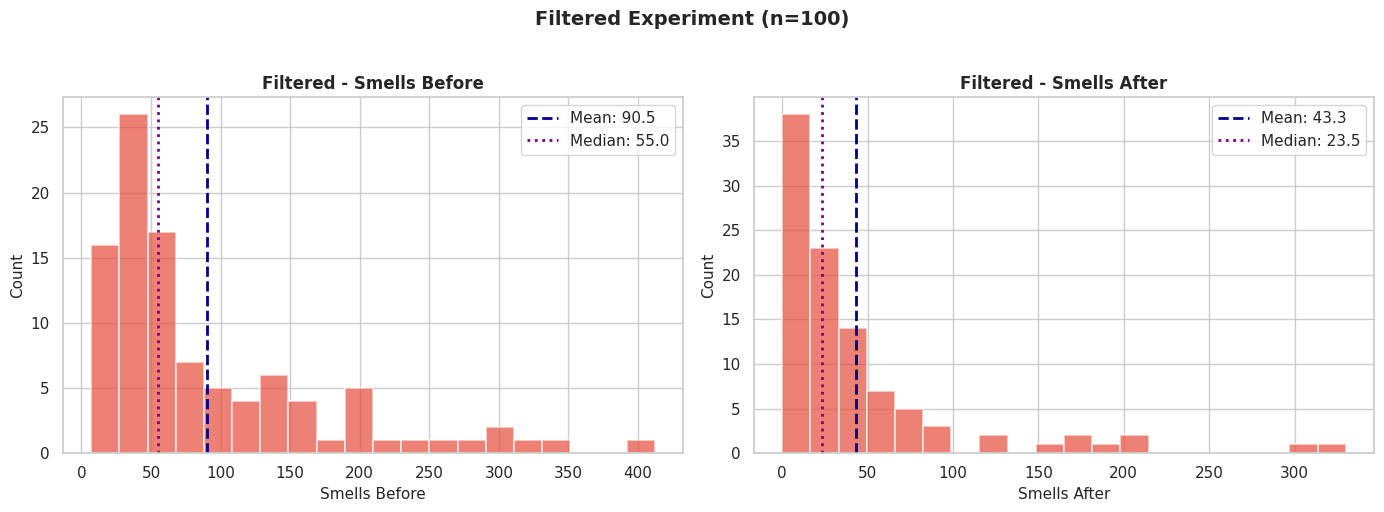

Filtered - Smells Before: mean=90.5, median=55.0, std=83.6
Filtered - Smells After:  mean=43.3, median=23.5, std=60.2


In [7]:
if 'Filtered' in exp_data:
    df = exp_data['Filtered']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Smells Before
    ax = axes[0]
    smells = df['smells_before'].dropna()
    ax.hist(smells, bins=20, color=EXP_COLORS['Filtered'], alpha=0.7, edgecolor='white', linewidth=1.2)
    ax.axvline(smells.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
    ax.axvline(smells.median(), color='purple', linestyle=':', linewidth=2, label=f'Median: {smells.median():.1f}')
    ax.set_xlabel('Smells Before', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Filtered - Smells Before', fontsize=12, fontweight='bold')
    ax.legend()
    
    # Smells After
    ax = axes[1]
    smells = df['smells_after'].dropna()
    ax.hist(smells, bins=20, color=EXP_COLORS['Filtered'], alpha=0.7, edgecolor='white', linewidth=1.2)
    ax.axvline(smells.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
    ax.axvline(smells.median(), color='purple', linestyle=':', linewidth=2, label=f'Median: {smells.median():.1f}')
    ax.set_xlabel('Smells After', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Filtered - Smells After', fontsize=12, fontweight='bold')
    ax.legend()
    
    plt.suptitle(f'Filtered Experiment (n={len(df)})', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(plots_dir / 'filtered_smells_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'Filtered - Smells Before: mean={df["smells_before"].mean():.1f}, median={df["smells_before"].median():.1f}, std={df["smells_before"].std():.1f}')
    print(f'Filtered - Smells After:  mean={df["smells_after"].mean():.1f}, median={df["smells_after"].median():.1f}, std={df["smells_after"].std():.1f}')

### Mixed Experiment - Smells Distribution

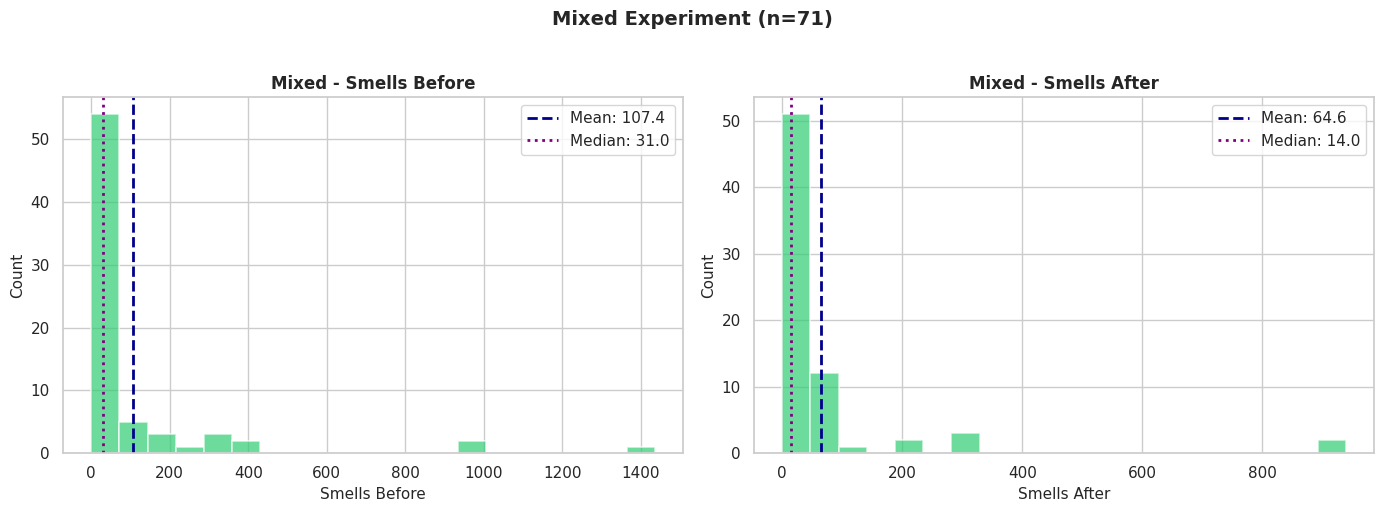

Mixed - Smells Before: mean=107.4, median=31.0, std=236.8
Mixed - Smells After:  mean=64.6, median=14.0, std=162.7


In [8]:
if 'Mixed' in exp_data:
    df = exp_data['Mixed']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Smells Before
    ax = axes[0]
    smells = df['smells_before'].dropna()
    ax.hist(smells, bins=20, color=EXP_COLORS['Mixed'], alpha=0.7, edgecolor='white', linewidth=1.2)
    ax.axvline(smells.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
    ax.axvline(smells.median(), color='purple', linestyle=':', linewidth=2, label=f'Median: {smells.median():.1f}')
    ax.set_xlabel('Smells Before', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Mixed - Smells Before', fontsize=12, fontweight='bold')
    ax.legend()
    
    # Smells After
    ax = axes[1]
    smells = df['smells_after'].dropna()
    ax.hist(smells, bins=20, color=EXP_COLORS['Mixed'], alpha=0.7, edgecolor='white', linewidth=1.2)
    ax.axvline(smells.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
    ax.axvline(smells.median(), color='purple', linestyle=':', linewidth=2, label=f'Median: {smells.median():.1f}')
    ax.set_xlabel('Smells After', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Mixed - Smells After', fontsize=12, fontweight='bold')
    ax.legend()
    
    plt.suptitle(f'Mixed Experiment (n={len(df)})', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(plots_dir / 'mixed_smells_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'Mixed - Smells Before: mean={df["smells_before"].mean():.1f}, median={df["smells_before"].median():.1f}, std={df["smells_before"].std():.1f}')
    print(f'Mixed - Smells After:  mean={df["smells_after"].mean():.1f}, median={df["smells_after"].median():.1f}, std={df["smells_after"].std():.1f}')

### Combined View - All Experiments

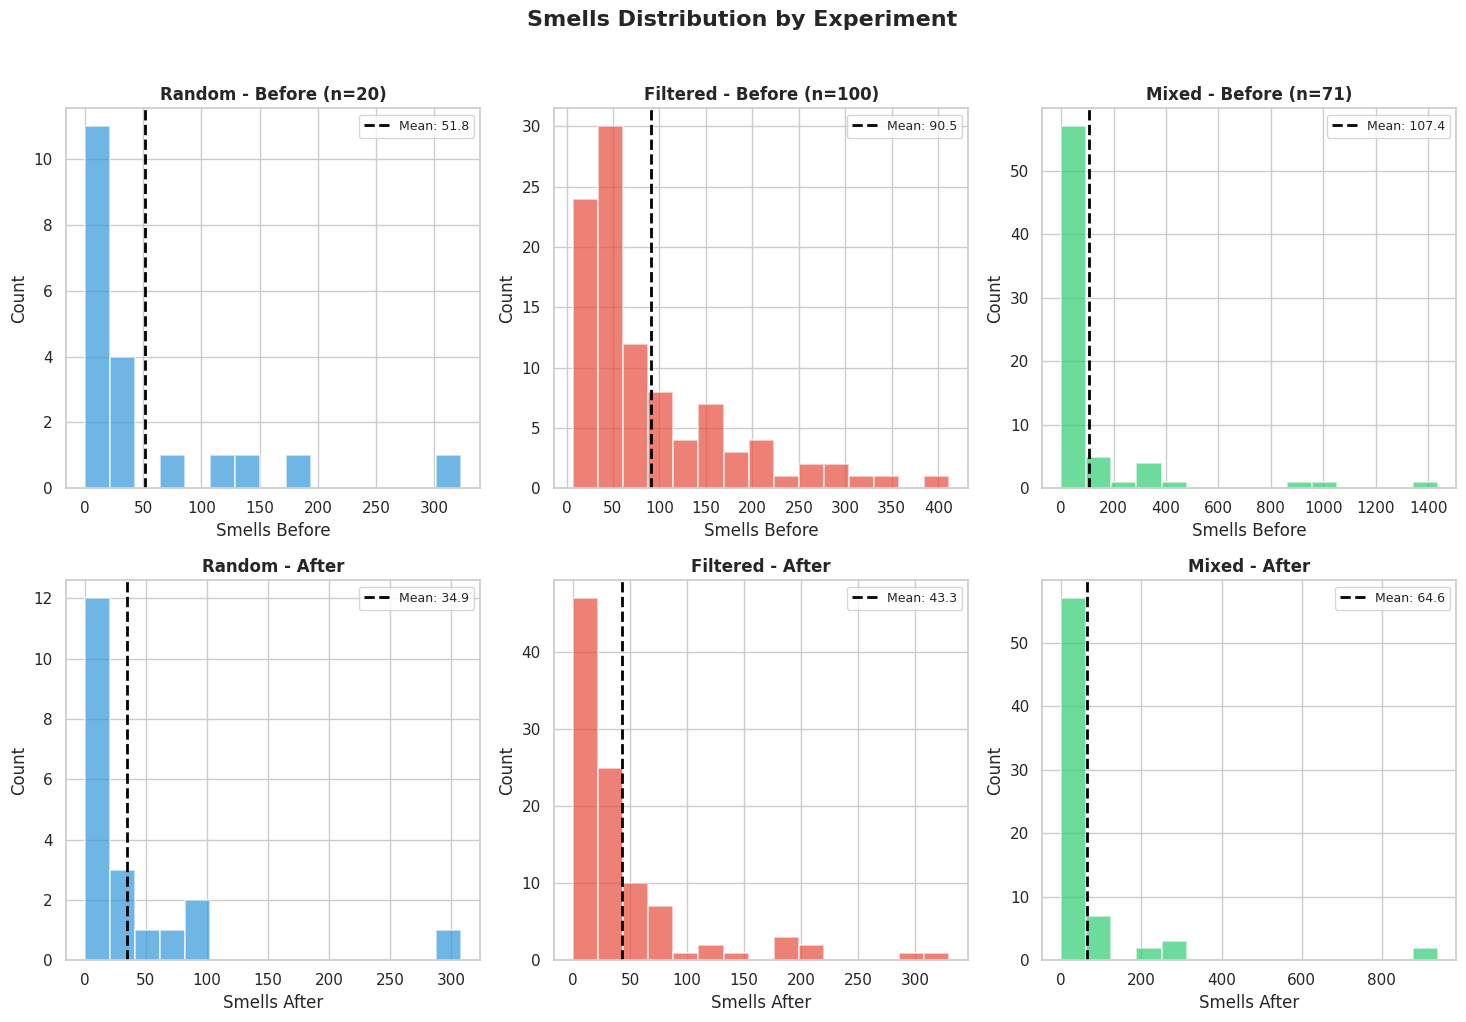

In [9]:
# Combined histogram comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, exp in enumerate(EXP_ORDER):
    if exp not in exp_data:
        continue
    df = exp_data[exp]
    
    # Row 0: Smells Before
    ax = axes[0, col]
    smells = df['smells_before'].dropna()
    ax.hist(smells, bins=15, color=EXP_COLORS[exp], alpha=0.7, edgecolor='white', linewidth=1.2)
    ax.axvline(smells.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
    ax.set_xlabel('Smells Before')
    ax.set_ylabel('Count')
    ax.set_title(f'{exp} - Before (n={len(df)})', fontweight='bold')
    ax.legend(fontsize=9)
    
    # Row 1: Smells After
    ax = axes[1, col]
    smells = df['smells_after'].dropna()
    ax.hist(smells, bins=15, color=EXP_COLORS[exp], alpha=0.7, edgecolor='white', linewidth=1.2)
    ax.axvline(smells.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
    ax.set_xlabel('Smells After')
    ax.set_ylabel('Count')
    ax.set_title(f'{exp} - After', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Smells Distribution by Experiment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'all_experiments_smells_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary Statistics

In [10]:
summary = all_data.groupby('repo').agg({
    'sha': 'count',
    'smells_before': ['mean', 'std'],
    'smells_after': ['mean', 'std'],
    'srr': ['mean', 'std', 'median'],
    'n_structural': ['mean', 'sum']
}).round(3)

summary.columns = ['Commits', 'SmellsBefore_Mean', 'SmellsBefore_Std', 
                   'SmellsAfter_Mean', 'SmellsAfter_Std',
                   'SRR_Mean', 'SRR_Std', 'SRR_Median',
                   'Structural_Mean', 'Structural_Total']

print('Repository Summary Statistics')
display(summary.sort_values('Commits', ascending=False))

summary.to_csv(plots_dir/'repo_summary.csv')
print(f"\nSaved to {plots_dir/'repo_summary.csv'}")

Repository Summary Statistics


,Commits,SmellsBefore_Mean,SmellsBefore_Std,SmellsAfter_Mean,SmellsAfter_Std,SRR_Mean,SRR_Std,SRR_Median,Structural_Mean,Structural_Total
repo,,,,,,,,,,
camel,223,44.516,69.789,44.843,69.594,-9.232,37.130,0.00,1.430,319
myfaces-trinidad,75,57.480,225.781,58.400,226.427,-0.339,27.955,0.00,1.613,121
incubator-brooklyn,15,6.067,13.599,6.200,14.118,-0.800,4.106,0.00,1.600,24
myfaces-extcdi,15,23.600,20.117,26.667,22.871,-13.129,15.136,-9.15,1.267,19
apex-core,12,4.667,3.916,5.500,3.802,-52.083,143.993,0.00,1.083,13
incubator-pinot,12,35.250,43.992,34.000,39.550,-11.912,36.436,-0.60,1.667,20
oozie,12,67.083,115.550,68.083,121.057,1.042,5.370,0.00,1.833,22
ode,12,98.250,134.226,99.250,133.480,-3.700,12.195,0.00,2.000,24
incubator-iotdb,12,0.000,0.000,0.000,0.000,NaN,NaN,NaN,2.333,28



Saved to /home/sing/refactor_project/data/plots/repo_summary.csv


In [11]:
# Experiment data summary
print('Experiment Smells Summary')
print('=' * 60)

exp_summary = []
for exp in EXP_ORDER:
    if exp in exp_data:
        df = exp_data[exp]
        exp_summary.append({
            'Experiment': exp,
            'Commits': len(df),
            'Smells Before (mean)': df['smells_before'].mean(),
            'Smells Before (median)': df['smells_before'].median(),
            'Smells After (mean)': df['smells_after'].mean(),
            'Smells After (median)': df['smells_after'].median(),
            'Reduction %': ((df['smells_before'].sum() - df['smells_after'].sum()) / df['smells_before'].sum() * 100)
        })

exp_summary_df = pd.DataFrame(exp_summary).set_index('Experiment')
display(exp_summary_df.round(2))

Experiment Smells Summary


,Commits,Smells Before (mean),Smells Before (median),Smells After (mean),Smells After (median),Reduction %
Experiment,,,,,,
Random,20,51.75,15.5,34.90,5.5,32.56
Filtered,100,90.47,55.0,43.27,23.5,52.17
Mixed,71,107.39,31.0,64.59,14.0,39.86


In [12]:
print('Overall Dataset Statistics')
print('=' * 40)
print(f'Total repositories: {all_data["repo"].nunique()}')
print(f'Total commits: {len(all_data)}')
print(f'Mean smells before: {all_data["smells_before"].mean():.2f}')
print(f'Mean smells after: {all_data["smells_after"].mean():.2f}')
print(f'Mean SRR: {all_data["srr"].mean():.4f}')
print(f'Positive SRR rate: {(all_data["srr"] > 0).mean() * 100:.1f}%')
if 'n_structural' in all_data.columns:
    print(f'Mean structural refactorings: {all_data["n_structural"].mean():.2f}')

Overall Dataset Statistics
Total repositories: 20
Total commits: 451
Mean smells before: 43.05
Mean smells after: 43.68
Mean SRR: -9.6012
Positive SRR rate: 10.9%
Mean structural refactorings: 1.54
